**Age Model Architecture**

input: image

output: age

regression model

Dataset: UTKFace
Link to download:

part 1: https://drive.usercontent.google.com/download?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&export=download&authuser=0&confirm=t&uuid=ed8e8e51-cb3c-4262-8314-d96bb87781d0&at=APcXIO0mPgJPDxNgg9CQHXWo3U2S:1772484352669

part 2: https://drive.usercontent.google.com/download?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&export=download&authuser=0&confirm=t&uuid=95a6db6e-c371-4d68-8bd1-f39a6f0eb339&at=APcXIO1iISpyVwxBCULNYhXmO8zf:1772485135426


part 3: https://drive.usercontent.google.com/download?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b&export=download&authuser=0&confirm=t&uuid=f8223bbf-436b-4eb6-b67c-914e3f714db2&at=APcXIO1CzF8SjAoIUitQd7krPgcI:1772485183395

### Get the Data

In [1]:
#!rm -rf datasets/faces/*

In [2]:
# Download and unzip the datasets from UTKface

import tarfile
import urllib.request
import os

download_url_part1 = "https://drive.usercontent.google.com/download?id=1mb5Z24TsnKI3ygNIlX6ZFiwUj0_PmpAW&export=download&authuser=0&confirm=t&uuid=ed8e8e51-cb3c-4262-8314-d96bb87781d0&at=APcXIO0mPgJPDxNgg9CQHXWo3U2S:1772484352669"
download_url_part2 = "https://drive.usercontent.google.com/download?id=19vdaXVRtkP-nyxz1MYwXiFsh_m_OL72b&export=download&authuser=0&confirm=t&uuid=95a6db6e-c371-4d68-8bd1-f39a6f0eb339&at=APcXIO1iISpyVwxBCULNYhXmO8zf:1772485135426"
download_url_part3 = "https://drive.usercontent.google.com/download?id=1oj9ZWsLV2-k2idoW_nRSrLQLUP3hus3b&export=download&authuser=0&confirm=t&uuid=f8223bbf-436b-4eb6-b67c-914e3f714db2&at=APcXIO1CzF8SjAoIUitQd7krPgcI:1772485183395"

# Download the datasets
download_urls = [download_url_part1, download_url_part2, download_url_part3]
face_path = os.path.join("datasets", "faces")
os.makedirs(face_path, exist_ok=True)

for dataset_num in range(len(download_urls)):
  dataset_folder_name = "part" + str(dataset_num + 1)
  if (not os.path.exists(os.path.join(face_path, dataset_folder_name)) and not os.path.exists(os.path.join(face_path, "images"))):
    print(f"Extracting dataset {dataset_num+1}...")
    faces_tar_location = os.path.join(face_path, "faces" + str(dataset_num+1) + ".tgz")
    urllib.request.urlretrieve(download_urls[dataset_num], faces_tar_location)

    # extract tar dataset
    faces_tgz = tarfile.open(faces_tar_location)
    faces_tgz.extractall(path="datasets/faces")
    faces_tgz.close()

    # remove tar file
    os.remove(faces_tar_location)

  else:
    print(f"dataset {dataset_num+1} already exists")



Extracting dataset 1...


/tmp/ipykernel_23/1526309747.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  faces_tgz.extractall(path="datasets/faces")


Extracting dataset 2...
Extracting dataset 3...


In [3]:
# Get IMBD Data

download_url = "https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/static/wiki_crop.tar"

imdb_raw_data_location = os.path.join(face_path, "imbd-face-dataset.tgz")
urllib.request.urlretrieve(download_url, imdb_raw_data_location)

imdb_faces_tgz = tarfile.open(imdb_raw_data_location)
imdb_faces_tgz.extractall(path="datasets/faces")
imdb_faces_tgz.close()

os.remove(imdb_raw_data_location)

/tmp/ipykernel_23/1431632241.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  imdb_faces_tgz.extractall(path="datasets/faces")


In [4]:
# Combine all data into one folder
import shutil

faces_images_path = os.path.join(face_path, "images")
os.makedirs(faces_images_path, exist_ok=True)

# Get source folders to copy image data from
source_folders = []
for dataset in range(len(download_urls)):
  dataset_path = os.path.join("./datasets/faces/part" + str(dataset+1))
  if (os.path.exists(dataset_path)):
    source_folders.append(dataset_path)

for folder in source_folders:
  file_names = os.listdir(folder)
  for file_name in file_names:
    shutil.move(os.path.join(folder, file_name), faces_images_path)
  os.rmdir(folder) # remove directory because we don't need it anymore

In [5]:
wiki_faces_path = os.path.join(face_path, "wiki_crop_processed")
os.makedirs(wiki_faces_path, exist_ok=True)

# Get source folders to copy image data from
source_folders = []
for dataset in range(0,100):
    dataset_path = os.path.join("./datasets/faces/wiki_crop", str(dataset))
    if (os.path.exists(dataset_path)):
        source_folders.append(dataset_path)

for folder in source_folders:
    wiki_file_names = os.listdir(folder)
    for wiki_file_name in wiki_file_names:
        file_split = wiki_file_name.split("_")
        unique_num = file_split[0]
        birth_year, photo_taken_year = file_split[1].split("-")[0], file_split[2].split(".")[0]
        age_in_photo = int(photo_taken_year) - int(birth_year)
        if (age_in_photo >= 0):
            new_file_name = f"{age_in_photo}_{unique_num}.jpg"
            os.rename(os.path.join(folder, wiki_file_name), os.path.join(folder, new_file_name))
            shutil.move(os.path.join(folder, new_file_name), wiki_faces_path)



In [6]:
!pip3 install pillow rich rich-pixels
!pip3 install setuptools==81.0
!pip3 install face-recognition
!pip3 install git+https://github.com/ageitgey/face_recognition_models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566239 sha256=91a3167850ba6f38c7db396f0303f83906ff0c6c6a06a7ee1c6685da18bd2f1d
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
  Cloning https://github.com/ageitgey/face_recognition_models to /tmp/pip-req-build-1ecd7cbg
  Running command git clone --filter=blob:none --quiet https://github.com/ageitgey/face_recognition_models /tmp/pip-req-build-1ecd7cbg
  Resolved https://github.com/ageitgey/face_recognition_mode

In [7]:
file_names = os.listdir(faces_images_path)
print(f"Number of images: {len(file_names)}")

wiki_file_names = os.listdir(wiki_faces_path)
print(f"Number of images: {len(wiki_file_names)}")

Number of images: 24109
Number of images: 55072


### Cropping Images & Adding Padding

In [8]:
# import face_recognition
# from PIL import Image, ImageOps
# import os

# #process one image
# def process_single_image(file_name, dir_basename):
#   image = face_recognition.load_image_file(os.path.join(f"./datasets/faces/{dir_basename}", file_name))
#   face_locations = face_recognition.face_locations(image, model="hog")
#   if len(face_locations) > 0: # face found in image

#     # Get Cropped Image
#     height, width = image.shape[:2]
#     top, right, bottom, left = face_locations[0]
    
#     box_h = bottom - top
#     box_w = right - left
#     pad_h = int(box_h * 0.33) # add padding to get hair, neck, etc.
#     pad_w = int(box_w * 0.33)

#     top = max(0, top-pad_h)
#     bottom = min(height, bottom+pad_h)
#     left = max(0, left-pad_w)
#     right = min(width, right+pad_w)

#     face_image = image[top:bottom, left:right]
#     pil_image = Image.fromarray(face_image)

#     # add padding
#     processed_image = ImageOps.pad(
#         pil_image,
#         (256,256),
#         Image.Resampling.LANCZOS,
#         (0,0,0) # black padding
#     )

#     processed_image.save(f"./datasets/faces/cropped/{file_name}")
#     return (file_name, True, "face_found_and_saved")

#   else: # image not successfully cropped
#     return (file_name, False, "no_face")

In [9]:
# from concurrent.futures import ProcessPoolExecutor, as_completed

# os.makedirs(os.path.join(face_path, "cropped"), exist_ok=True)
# test_set = [file_names, wiki_file_names] # test batch
# dir_basenames = ["images", "wiki_cropped_processed"]

# results = []
# futures = []
# num_workers = 20
# images_already_processed = os.listdir("./datasets/faces/cropped")

# with ProcessPoolExecutor(max_workers=num_workers) as ppe:
#     for i in range(2):
#       for img in test_set[i]:
#         if img not in images_already_processed:
#           submission = ppe.submit(process_single_image, img, dir_basenames[i])
#           futures.append(submission)
#       for fut in as_completed(futures):
#         results.append(fut.result())

# num_success = 0
# for fn, success_boolean, msg in results:
#   if success_boolean:
#     num_success += 1

# print(f"Processed {num_success}/{len(test_set)} images successfully")

In [10]:
cropped_images_url = "https://drive.usercontent.google.com/download?id=1gNbGJM7EMDUGWTAlmqymp_UWcHRXuu-k&export=download&authuser=0&confirm=t&uuid=de936aea-b39f-4d6c-80fa-ad0b8069d340&at=AGN2oQ2XTBoJ1ZQu-fYe9B2QTCpt:1773946480497"

image_locations = os.path.join(face_path, "pp_images.tgz")
urllib.request.urlretrieve(cropped_images_url, image_locations)

pp_images_tgz = tarfile.open(image_locations)
pp_images_tgz.extractall(path="./datasets/faces")
pp_images_tgz.close()

os.remove(image_locations)


/tmp/ipykernel_23/4147550256.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  pp_images_tgz.extractall(path="./datasets/faces")


In [11]:
import random

# Shuffling image data before splitting it

random.seed(49328042)
images_shuffled = os.listdir("./datasets/faces/cropped")
random.shuffle(images_shuffled)

age_labels = []

for file in images_shuffled:
    age_label = int(file[0:file.index('_')])
    age_labels.append(age_label)


In [12]:
# Split the data into training, validation, and testing sets

print(len(images_shuffled))

train_data = images_shuffled[:47001]
train_labels = age_labels[:47001]

validation_data = images_shuffled[47001:51501]
validation_labels = age_labels[47001:51501]

testing_data = images_shuffled[51501:]
testing_labels = age_labels[51501:]


56528


In [13]:
# Create image set directories based on labels

import os, shutil, pathlib

original_dir = "./" + str(pathlib.Path("datasets/faces/cropped"))
base_training_dir = "./" + str(pathlib.Path("datasets/faces/training"))

def make_data_sets(subdir, starting_index, ending_index):
    for img_index in range(starting_index, ending_index):
        dir_path = f"{base_training_dir}/{subdir}/{str(age_labels[img_index])}"
        os.makedirs(dir_path, exist_ok=True)

        image_path = os.path.join(original_dir, images_shuffled[img_index])
        if (image_path not in os.listdir(dir_path)):
            shutil.move(image_path, dir_path)

if (len(os.listdir(original_dir)) > 0):
    make_data_sets("train", 0, 47000)
    make_data_sets("validation", 47001, 51501)
    make_data_sets("test", 51501, 56000)



In [14]:
# Build tf.data pipelines with labels parsed directly from file paths.
# Important: shuffle file paths (cheap), not decoded images (expensive).

import tensorflow as tf
import os
from pathlib import Path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # lower memory pressure vs 64
AUTOTUNE = tf.data.AUTOTUNE

def decode_image_and_label(path, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, IMG_SIZE, method="bilinear")
    image = tf.cast(image, tf.float32)

    # Parent folder name is the age label (e.g. .../train/34/image.jpg -> 34.0).
    age_str = tf.strings.split(path, os.sep)[-2]
    label = tf.strings.to_number(age_str, out_type=tf.float32)

    return image, label

def make_dataset(split_name, training=False):
    split_dir = Path(base_training_dir) / split_name
    pattern = str(split_dir / "*" / "*.jpg")

    # Create file-path dataset first, then shuffle paths (strings), not image tensors.
    file_ds = tf.data.Dataset.list_files(pattern, shuffle=False)
    if training:
        file_ds = file_ds.shuffle(50000, seed=42, reshuffle_each_iteration=True)

    ds = file_ds.map(
        lambda p: decode_image_and_label(p, training=training),
        num_parallel_calls=AUTOTUNE,
    )

    # Skip occasional corrupt files instead of crashing the input pipeline.
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_dataset = make_dataset("train", training=True)
validation_dataset = make_dataset("validation", training=False)
test_dataset = make_dataset("test", training=False)

print("Datasets loaded with deterministic path-based labels.")
for imgs, labels in train_dataset.take(1):
    print(f"Batch images: {imgs.shape}, labels sample: {labels[:8].numpy()}")

2026-04-11 05:53:04.812865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775886785.212805      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775886785.340540      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775886786.344550      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775886786.344595      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775886786.344598      23 computation_placer.cc:177] computation placer alr

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Datasets loaded with deterministic path-based labels.
Batch images: (32, 224, 224, 3), labels sample: [53. 48. 58. 44. 28. 28. 56. 35.]


In [15]:
for data_batch, labels_batch in train_dataset:
    print(f"Shape of data set: {data_batch.shape}")
    print(f"Shape of label set: {labels_batch.shape}")
    break

Shape of data set: (32, 224, 224, 3)
Shape of label set: (32,)


### Building the CNN

In [16]:
%pip install tensorflow
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(224, 224, 3), name="image")

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

x = data_augmentation(inputs)

# Strong baseline for age regression: pretrained EfficientNet backbone + regression head.

backbone = keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs,
    pooling=None,
 )

backbone.trainable = False  # Stage 1: train head first

x = keras.applications.resnet_v2.preprocess_input(x)
x = backbone(x, training=False)

# CNN Head ---

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, name="predicted_age")(x)

cnn_model = keras.Model(inputs, outputs, name="age_effnetb0_regressor")
cnn_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "age_effnetb0_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_age (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,839,425 (90.94 MB)

 Trainable params: 270,529 (1.03 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [18]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

# Prevent TF from grabbing all GPU memory up front.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth on: {gpu}")
    except Exception as err:
        print(f"Could not set memory growth on {gpu}: {err}")

GPUs available: 2
Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'): Physical devices cannot be modified after being initialized
Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'): Physical devices cannot be modified after being initialized


In [19]:
import re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import register_keras_serializable

# Custom metric to track percent of age predictions correct within N-year tolerance.
@register_keras_serializable(package="Custom")
class WithinNYears(tf.keras.metrics.Metric):
    def __init__(self, tolerance=None, dtype=None, name=None, **kwargs):
        # Backward-compatible load path: if older saved configs omit tolerance
        if tolerance is None and isinstance(name, str):
            match = re.match(r"within_(\d+)_years", name)
            if match:
                tolerance = int(match.group(1))

        if tolerance is None:
            tolerance = 2

        super().__init__(name=name or f"within_{tolerance}_years", dtype=dtype, **kwargs)
        self.tolerance = int(tolerance)
        self.correct = self.add_weight(name="correct", initializer="zeros")
        self.total = self.add_weight(name="total", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.squeeze(y_pred, axis=-1) # get last tensor (output) and transform (batch_size,1) to (batch_size,)
        y_true = tf.cast(y_true, tf.float32) 
        within = tf.abs(y_true - y_pred) <= self.tolerance
        self.correct.assign_add(tf.reduce_sum(tf.cast(within, tf.float32))) # convert booleans to floats and get total sum and add to correct
        self.total.assign_add(tf.cast(tf.size(y_true), tf.float32)) # total is just size of y_true

    def result(self):
        return self.correct / self.total
    
    def reset(self): # runs once per epoch
        self.correct.assign(0)
        self.total.assign(0)

    def get_config(self):
        config = super().get_config()
        config.update({"tolerance": self.tolerance})
        return config

In [20]:
import tensorflow as tf
from tensorflow import keras

# Stage 1 optimizer/schedule (head training while backbone frozen).
lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae", factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

cnn_model.compile(
    loss=keras.losses.Huber(delta=4.0),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["mae", WithinNYears(2), WithinNYears(5), WithinNYears(10)]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="cnn_model_best.keras",
        save_best_only=True,
        monitor="val_mae",
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    lr_schedule,
]

print("Stage 1 model compiled.")

Stage 1 model compiled.


In [21]:
# # Stage 1: train regression head.
history_stage1 = cnn_model.fit(
    train_dataset,
    epochs=40,
    validation_data=validation_dataset,
    callbacks=callbacks,
 )

# Stage 2: unfreeze top backbone layers and fine-tune at lower LR.
backbone = cnn_model.get_layer("resnet50v2")
backbone.trainable = True

# Keep early layers frozen; fine-tune only deeper layers.
for layer in backbone.layers[:-40]:
    layer.trainable = False

cnn_model.compile(
    loss=keras.losses.Huber(delta=4.0),
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["mae", WithinNYears(2), WithinNYears(5), WithinNYears(10)]
)

history_stage2 = cnn_model.fit(
    train_dataset,
    epochs=75,
    validation_data=validation_dataset,
    callbacks=callbacks,
 )

training_history = history_stage2

Epoch 1/40


I0000 00:00:1775886838.877266     113 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1469/Unknown 179s 113ms/step - loss: 50.2918 - mae: 14.4304 - within_10_years: 0.4575 - within_2_years: 0.1073 - within_5_years: 0.2508

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_mae improved from inf to 9.41698, saving model to cnn_model_best.keras
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 198s 126ms/step - loss: 50.2858 - mae: 14.4289 - within_10_years: 0.4575 - within_2_years: 0.1073 - within_5_years: 0.2508 - val_loss: 30.5573 - val_mae: 9.4170 - val_within_10_years: 0.6209 - val_within_2_years: 0.1671 - val_within_5_years: 0.3571 - learning_rate: 0.0010
Epoch 2/40
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 36.6230 - mae: 10.9734 - within_10_years: 0.5493 - within_2_years: 0.1348 - within_5_years: 0.3067
Epoch 2: val_mae improved from 9.41698 to 9.28048, saving model to cnn_model_best.keras
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 186s 126ms/step - loss: 36.6230 - mae: 10.9734 - within_10_years: 0.5493 - within_2_years: 0.1348 - within_5_years: 0.3067 - val_loss: 30.0560 - val_mae: 9.2805 - val_within_10_years: 0.6260 - val_within_2_years: 0.1727 - val_within_5_years: 0.3678 - learning_rate: 0.0010
Epoch 3/40
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step 

### Tuning Model

In [22]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    mae = history.history["mae"]
    val_mae = history.history["val_mae"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(mae) + 1)

    plt.plot(epochs, mae, "bo", label="Training Mae")
    plt.plot(epochs, val_mae, "b", label="Validation Mae")
    plt.title("Training and Validation MAE")
    plt.xlabel("Epochs")
    plt.ylabel("MAE")
    plt.legend()
    plt.figure()

    plt.plot(epochs[1:], loss[1:], "bo", label="Training Loss")
    plt.plot(epochs[1:], val_loss[1:], "b", label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


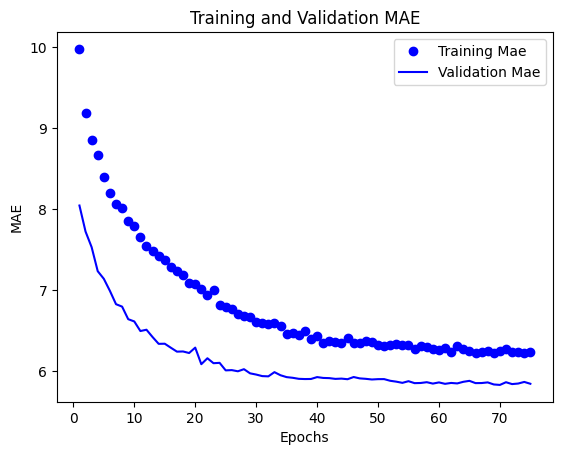

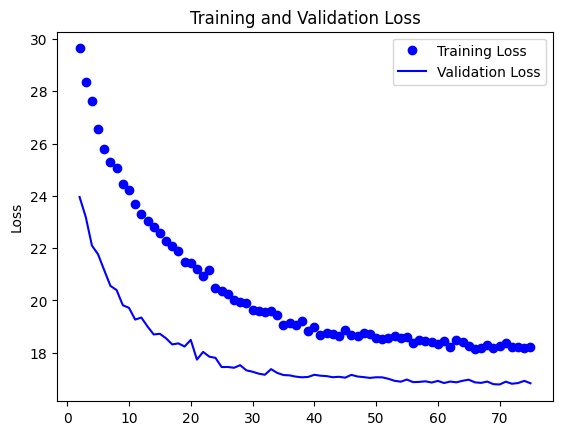

In [23]:
plot_training_history(training_history)

### Evaluating the Model

In [24]:
# custom_objects = {"WithinNYears": WithinNYears}
# test_model = keras.models.load_model("cnn_model_best.keras", custom_objects=custom_objects)
# test_loss = test_model.evaluate(test_dataset)
# print(f"Test Loss: {test_loss[0]:.3f}\nTest MAE: {test_loss[1]:.3f}\nTest within 10y: {test_loss[4]:.3f}\nTest within 5y: {test_loss[3]:.3f}\nTest within 2y: {test_loss[2]:.3f}")

In [25]:
# from PIL import Image, ImageOps
# import face_recognition
# import os

# !pwd

# image = face_recognition.load_image_file(os.path.join("./", "lisa.jpg"))
# face_locations = face_recognition.face_locations(image, model="hog")

# if len(face_locations) > 0: # face found in image

#     # Get Cropped Image
#     height, width = image.shape[:2]
#     top, right, bottom, left = face_locations[0]
    
#     box_h = bottom - top
#     box_w = right - left
#     pad_h = int(box_h * 0.33) # add padding to get hair, neck, etc.
#     pad_w = int(box_w * 0.33)

#     top = max(0, top-pad_h)
#     bottom = min(height, bottom+pad_h)
#     left = max(0, left-pad_w)
#     right = min(width, right+pad_w)

#     face_image = image[top:bottom, left:right]
#     pil_image = Image.fromarray(face_image)

#     # add padding
#     processed_image = ImageOps.pad(
#         pil_image,
#         (256,256),
#         Image.Resampling.LANCZOS,
#         (0,0,0) # black padding
#     )

#     processed_image.save(f"lisa_cropped.jpg")

In [26]:
import numpy as np
from PIL import Image
from tensorflow import keras
import os

img_path = "lisa_cropped.jpg"
model_path = "cnn_model_best.keras"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Could not find {img_path}. Run the crop cell first.")

if "test_model" not in globals():
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Could not find {model_path}.")
    test_model = keras.models.load_model(model_path, compile=False)

img = Image.open(img_path)
img_array = np.array(img, dtype=np.float32)
img_batch = np.expand_dims(img_array, axis=0)

print(f"Input tensor shape: {img_batch.shape}")

pred = test_model.predict(img_batch, verbose=0)
predicted_age = float(pred[0][0])
print(f"Predicted age: {predicted_age:.2f}")

FileNotFoundError: Could not find lisa_cropped.jpg. Run the crop cell first.